In [19]:
# pandas는 표(엑셀) 형태의 데이터를 다루는 도구입니다. 보통 pd라는 짧은 이름으로 줄여서 씁니다.
import pandas as pd

# DataFrame은 엑셀 표처럼 행(row)과 열(column) 로 데이터를 저장하는 자료구조입니다.
# 중괄호 {} 안의 "이름": [값들] 한 줄이 컬럼(세로 열) 하나가 됩니다.
# tempearature: 기온 데이터 → 입력값 X
# sales: 실제 떡볶이 판매량 → 정답 Y
df = pd.DataFrame({
    "temperature": [10, 7, 4, 0],  #temperature 컬럼 (기온)
    "sales": [30, 50, 60, 80]      #sales 컬럼 (실제 판매량)
})

# display 는 표를 보기좋게 출력해줍니다. (print(df) 와 비슷하지만 더 깔끔합니다)
# 맨 왼쪽에 0,1,2,3 은 각 행(row)의 번호(인덱스) 입니다.
display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [20]:
# a : 기울기, b : 절편. 지금은 우리가 직접 정한 임시 값입니다.
a = -4
b = 80

# range(len(df)): 0,1,2,3 처럼 데이터(행) 번호를 차례대로 만들어 줍니다. (len(df) = 4)
# 즉, df 의 각 행을 위애서부터 하나씩 꺼내며 반복합니다.
for i in range(len(df)):
    # df.loc[i, "temperature"] : i 번째 행의 temperature(기온) 값 하나를 꺼냅니다.
    x = df.loc[i, "temperature"]
    pred = a * x + b    # pred 는 현재 a, b로 계산한 예측값입니다. (예측값 = a * x + b)
    # 계산 과정이 눈에 보이도록 식을 그대로 출력합니다.
    print(f"X={x}일때 예측값 = {a} * {x} + {b} = {pred}")
    

X=10일때 예측값 = -4 * 10 + 80 = 40
X=7일때 예측값 = -4 * 7 + 80 = 52
X=4일때 예측값 = -4 * 4 + 80 = 64
X=0일때 예측값 = -4 * 0 + 80 = 80


In [21]:
# a, b는 위에서 정한 -4, 80 을 그대로 사용합니다.
a = -4
b = 80
# df 의 각 행을 하나씩 꺼내면서 예측값과 오차를 계산합니다.
# (이 셀에서는 df.loc로 행 번호 i 를 이용해 값을 하나씩 꺼냅니다.)
for i in range(len(df)):
    x = df.loc[i, "temperature"] # i번째 행의 기온(입력값 X)
    y = df.loc[i, "sales"] # i번째 행의 실제 판매량(정답 Y)
    pred = a * x + b # 예측값 계산 (a * x + b)
    error = pred + y # 오차 = 예측값 - 실제값
    
    print(f"X={x}, 실제값 = {y}, 예측값 = {pred}, 오차 = {pred} - {y} = {error}")
    print("=" * 30)

X=10, 실제값 = 30, 예측값 = 40, 오차 = 40 - 30 = 70
X=7, 실제값 = 50, 예측값 = 52, 오차 = 52 - 50 = 102
X=4, 실제값 = 60, 예측값 = 64, 오차 = 64 - 60 = 124
X=0, 실제값 = 80, 예측값 = 80, 오차 = 80 - 80 = 160


In [22]:
a = -4
b = 80

square_sum = 0 # 오차 제곱을 모드 더해서 담아 둘 변수입니다. (처음엔 0에서 시작)

# 모든 행을 돌면서 '오차를 제곱한 값' 을 square_sum 에 차곡차곡 더합니다.
for i in range(len(df)):
    x = df.loc[i, "temperature"]
    y = df.loc[i, "sales"]
    pred = a * x + b
    error = pred - y                # 예측값
    error_square = error * error    # 오차 = 예측값 - 실제값
    square_sum = square_sum + error_square # 오차 제곱 (error ** 2 와 같음, 음수를 양수로 만든다)
    
n = len(df)         #데이터(행) 개수 (여기서는 4)
cost = square_sum / n #  Cost = 오차 제곱의 평균 (제곱들의 합 ÷ 개수)

print(f"오차 제곱의 합: {square_sum}")
print(f"데이터 개수: {n}")
print(f"Cost: {cost: .4f}")  # 소수점 4자리로 깔끔하게 출력

오차 제곱의 합: 120
데이터 개수: 4
Cost:  30.0000


In [23]:
def calculate_cost(a, b):
#     -------------  calculate_cost 함수 설명 -------------
#     입력 값:
#         a : 직선의 기울기
#         b : 직선의 절편
#     처리 과정:
#         1) 모든 데이터에 대해 예측값의 계산한다.
#         2) 실제값과 비교해 오차를 계산한다.
#         3) 오차를 제곱한다.
#         4) 오차 제곱의 평균을 Cost 로 계산한다.
#     반환값: 
#         cost : 현재 a, b 가 얼마나 좋은지 (얼마나 안 틀렸는지) 나타내는 숫자
#     ----------------------------------------------------
    square_sum = 0      # 오차 제곱의 합
    for i in range(len(df)):
        x = df.loc[i, "temperature"]
        y = df.loc[i, "sales"]
        pred = a * x + b                        # 1) 예측값을 계산하고
        error = pred - y                        # 2) 오차를 계산하고
        error_square = error * error            # 3) 오차를 제곱하고
        square_sum = square_sum + error_square  # 4) 오차 제곱을 더한다

    n = len(df)                                 # 5) 오차 제곱의 평균 = Cost
    cost = square_sum / n                       # 6) 계산한 Cost 를 돌려준다
    return cost

# 함수가 잘 동작하는지 확인 : a = -4, b = 80 일 때  Cost (위에서 직접 구한 30.0 이 나와야 함)
print("calculate_cost(-4, 80) =", calculate_cost(-4, 80))

calculate_cost(-4, 80) = 30.0


In [24]:
# 함수를 사용하면 직선 하나의 Cost를 한 줄로 구할 수 있습니다.
cost1 = calculate_cost(-4, 80)      # 첫 번째 직선 Y = -4X + 80 의 Cost
cost2 = calculate_cost(-4.9, 81)    # 두 번째 직선 Y = -4.9X + 81 의 Cost

# 두 직선 중 Cost 가 더 작은 쪽이 데이터를 더 잘 설명하는 직선입니다.
print(f"Y = -4X + 80 의 Cost:{cost1: .4f}")
print(f"Y = -4.9X + 81 의 Cost:{cost1: .4f}")

Y = -4X + 80 의 Cost: 30.0000
Y = -4.9X + 81 의 Cost: 30.0000


In [25]:
# a_values: 비교해 볼 여러 개의 a(기울기) 값들을 리스트로 모아 둔 것
a_values = [-6, -5, -4, -3, -2]
b = 80          #  b(절편)는 80으로 고정 하고, a만 바꿔 봅니다.

# cost_values : 각 a에 대한 Cost를 저장해 둘 빈 리스트 (뒤에서 그래프 y축으로 사용)
cost_values = []

# a_values 안의 값을 하나씩 a에 넣어가며 Cost를 계산합니다.
for a in a_values:
    cost = calculate_cost(a, b)     # 각 a 값에 대한 Cost 계산
    cost_values.append(cost)        # 계산한 Cost를 리스트 맨 뒤에 추가(저장)
    print(f"a={a}, b={b}, Cost={cost:.4f}") 

a=-6, b=80, Cost=65.0000
a=-5, b=80, Cost=6.2500
a=-4, b=80, Cost=30.0000
a=-3, b=80, Cost=136.2500
a=-2, b=80, Cost=325.0000


In [26]:
# !pip install matplotlib

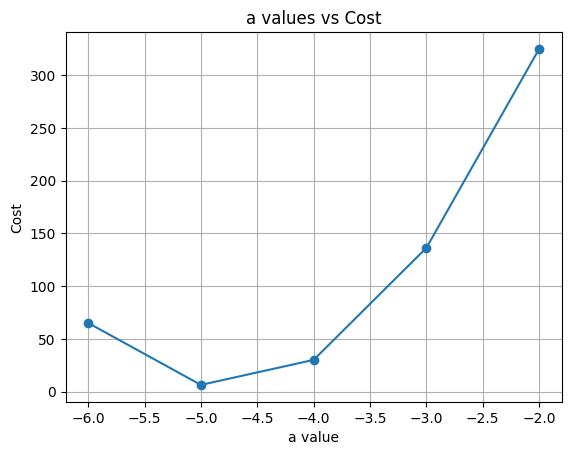

In [27]:
import matplotlib.pyplot as plt     # matplotlib : 그레프를 그리는 도구 (plt 라는 짧은 이름으로 사용)

plt.figure()
# plot(x축 값, y축 값) : a_values를 x 축 , cost_values를 y축으로 점을 찍고 선으로 잇습니다.
# marker = 'o' : 각 데이터 위치에 동그라미 점을 표시합니다.
plt.plot(a_values, cost_values, marker='o')
plt.title("a values vs Cost")       # 그레프 제목
plt.xlabel("a value")               # x 축 이름: a값
plt.ylabel("Cost")                  # y 축 이름: Cost
plt.grid(True)                      # 눈금선(격자) 표시 → 값을 읽기 쉬워집니다.
plt.show()                          # 지금까지 그린 그레프 화면에 보여줍니다.

In [28]:
b = 80  # b 는 80으로 고정하고, a만 손으로 조금씩 바꿔 봅니다.

# a 를 -4 → -4.5 → -5 로 바꿔 보면서 그때그때 Cost가 어떻게 변하는지 확인합니다.
a = -4

cost = calculate_cost(a, b)         # 현재 a, b 로 Cost 계산
print(f"a = {a}, b = {b}, Cost = {cost:.4f}")

a = -4.5
cost = calculate_cost(a, b)         # a를 바꾼 뒤 Cost 계산
print(f"a = {a}, b = {b}, Cost = {cost:.4f}")

a = -5
cost = calculate_cost(a, b)         # a를 또 바꾼 뒤 Cost 계산
print(f"a = {a}, b = {b}, Cost = {cost:.4f}")

a = -4, b = 80, Cost = 30.0000
a = -4.5, b = 80, Cost = 7.8125
a = -5, b = 80, Cost = 6.2500


In [29]:
# 시작 직선 : Y = -4X + 80
a = -4
b = 80
learning_rate = 0.001   #학습률(보폭): 한 번에 조금씩만 움직이도록 작은 값 사용
epochs = 1000           #전체 데이터를 1000번 반복해서 학습

n = len(df)             #데이터(행) 개수
cost_history = []       #매 epoch 의 Cost 를 저장 할 리스스 (뒤에서 그래프로 그림)

# 학습을 시작하기 전, 처음 직선의 값과 Cost를 기억해 둡니다.
# (나중에 학습 전 후 를 비교할 때 사용합니다.)
initial_a = a
initial_b = b
initial_cost = calculate_cost(a, b)
print(f"학습 전 Cost: {initial_cost:.4f}")

학습 전 Cost: 30.0000


In [34]:
# epochs: 전채 데이터를 몇 번 반복해서 학습할지 정하는 값.
# 예: epochs = 1000 이면 전체 데이터를 1000번 반복해서 보면서 a, b를 수정함
for epoch in range(epochs):
    
    # grad_a : a를 수정하기 위해 사용할 Gradient 누적값
    # grad_b : b를 수정하기 위해 사용할 Gradient 누적값
    # 매 반복(epoch)마다 새로 계산해야 하므로 0으로 초기화
    grad_a  = 0
    grad_b  = 0
    
    # 전채 데이터를 한 행씩 확인
    for i in range(len(df)):
        x = df.loc[i, "temperature"]
        y = df.loc[i, "sales"]
        # 현재 a, b로 예측값 계산
        # H(x) = ax + b
        pred = a * x + b
        
        # Gradient 계산에는 미분 결과인 H(x)-y를 사용
        # 즉, 예측값 - 실제값
        pred_minus_actual = pred - y
        
        # a에 대한 Gradient 누적
        # ∂cost/∂a = x * (H(x)-y)
        grad_a = grad_a + pred_minus_actual * x
        
        # b에 대한 Gradient 누적
        # ∂cost/∂b = x * (H(x)-y)
        grad_b = grad_b + pred_minus_actual

    # 전채 데이터 개수로 나누어 평균 Gradient 계산
    n = len(df)
    grad_a = grad_a / n    
    grad_b = grad_b / n    

    # Gradient Descent 공식으로 a, b 수정
    # 새 값 = 현재 값 - learning_rate *  Gradient
    a = a - learning_rate * grad_a
    b = b - learning_rate * grad_b

    # 수정된 a, b 로 현재 Cost 계산 후 저장
    cost = calculate_cost(a,b)
    cost_history.append(cost)

    # 100번 반복할 때마다 중간 결과 출력
    if epoch % 100 == 0:
        print(f"epoch={epoch}, Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")


epoch=0, Cost=27.9005, a=-4.0325, b=79.9960
epoch=100, Cost=4.4233, a=-4.7666, b=79.9185
epoch=200, Cost=4.4137, a=-4.7787, b=79.9331
epoch=300, Cost=4.4089, a=-4.7808, b=79.9484
epoch=400, Cost=4.4044, a=-4.7827, b=79.9632
epoch=500, Cost=4.4002, a=-4.7846, b=79.9776
epoch=600, Cost=4.3963, a=-4.7864, b=79.9916
epoch=700, Cost=4.3926, a=-4.7881, b=80.0050
epoch=800, Cost=4.3891, a=-4.7898, b=80.0181
epoch=900, Cost=4.3859, a=-4.7914, b=80.0307


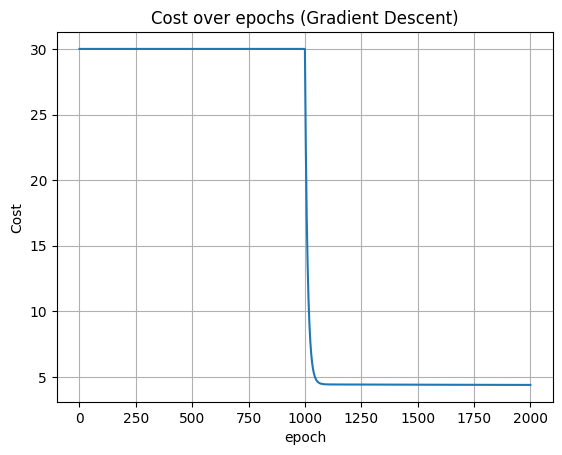

In [35]:
import matplotlib.pyplot as plt   # (위에서 이미 import 했지만, 이 셀만 봐도 알 수 있게 되어 다시 적어 둡니다.)

plt.figure()    # 새 그래프 판 만들기
# x축 : epoch 번호 (0,1,2, ....), y축 : 그 epoch 의 Cost
# range(len(cost_history)) 는 0부터 저장된 Cost 개수 만큼의 번호를 만들어 줍니다.
plt.plot(range(len(cost_history)), cost_history)
plt.title("Cost over epochs (Gradient Descent)")
plt.xlabel("epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [37]:
#학습 전 값: 11번 셀에서 학습 시작 전에 저장해 둔 initial_a, initial_b, initial_cost 를 사용합니다.
#학습 후 값: 11번 셀의 반복문이 끝난 뒤 남아있는 a, b 가 곧 학습된 값입니다.
final_a = a
final_b = b
final_cost = calculate_cost(final_a, final_b) #학습된 a, b의 Cost

print("학습 전")
print(f"a = {initial_a:.4f}")
print(f"b = {initial_b:.4f}")
print(f"Cost = {initial_cost:.4f}\n")

print("학습 후")
print(f"a = {final_a:.4f}")
print(f"b = {final_b:.4f}")
print(f"Cost = {final_cost:.4f}")

학습 전
a = -4.0000
b = 80.0000
Cost = 30.0000

학습 후
a = -4.7930
b = 80.0428
Cost = 4.3829
